Analysis with creation of heatmaps, statistical calculations, and McNemar P-values 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.inter_rater import cohens_kappa
from statsmodels.stats.proportion import proportion_confint

In [2]:
# Creating dummy variables 

# Import dataset (literal_eval is required so that lists in accept are interpreted as lists)
table = pd.read_csv("C:/Users/Julia/Desktop/Full text vs Abstract/4_analysis/GPT_high_temp100.csv", 
                    converters={'accept': literal_eval,'abstract_gpt-5-2025-08': literal_eval, 'full_text_gpt-5-2025-08': literal_eval})

# Create dummy variables for the accept column
table = table.join(pd.get_dummies(table["accept"].explode()).groupby(level=0).sum())
# Create dummy variables for the abstract labels
table = table.join(pd.get_dummies(table["abstract_gpt-5-2025-08"].explode(), prefix="ABSTRACT").groupby(level=0).sum())
#Create dummy variables for the full-text labels
table = table.join(pd.get_dummies(table["full_text_gpt-5-2025-08"].explode(), prefix="FULL_TEXT").groupby(level=0).sum())

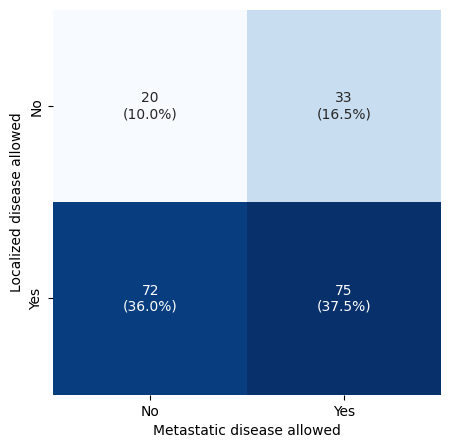

In [3]:
# Heatmap showing the distribution of localized and metastatic disease in the dataset
fig = plt.figure(figsize=(5, 5))
LM_cross_tab = pd.crosstab(table['LOCAL'], table['METASTATIC'])

# Add percentage to the absolute number
labels = np.array([
    f"{count}\n({count/2:.1f}%)" # Total number is always 200 so divide by to to get percentage
    for count in LM_cross_tab.values.flatten()
]).reshape(LM_cross_tab.shape)

#creation of the heatmap
sns.heatmap(
    LM_cross_tab,
    annot=labels,
    fmt="",
    cmap="Blues"
)

plt.xlabel("Metastatic disease allowed")
plt.ylabel("Localized disease allowed")
plt.xticks([0.5, 1.5], ["No", "Yes"])
plt.yticks([0.5, 1.5], ["No", "Yes"])

# Remove the colorbar but keep the width of the heatmap
plt.gca().collections[0].colorbar.remove()

plt.show()
fig.savefig("LM_distribution_percentage.png", dpi=300, bbox_inches="tight")

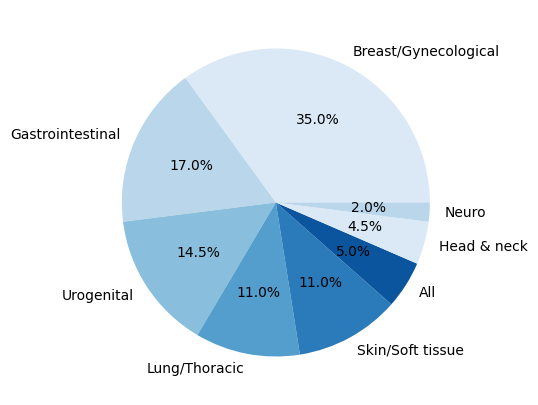

In [4]:
# Pie chart of tumor types in the analyzed papers
fig = plt.figure(figsize=(5, 5))
sns.set_palette("Blues")
table["family"].value_counts().plot.pie(autopct="%1.1f%%")
plt.ylabel("")
plt.show()

fig.savefig("Tumor_types.png", dpi=300, bbox_inches="tight")

In [5]:
#Calculate Cohen's kappa for the interannotator agreement

#For localized disease
both_local = 140
paul_local = 0
julia_local = 7
both_not_local = 53

table_local = np.array([
    [both_local, paul_local],
    [julia_local, both_not_local]
])

kappa_local = cohens_kappa(table_local)

print("Cohen's kappa for LOCAL:", kappa_local)

#For metastatic disease
both_metastatic = 108
paul_metastatic = 2
julia_metastatic = 0
both_not_metastatic =90

table_metastatic = np.array([
    [both_metastatic, paul_metastatic],
    [julia_metastatic, both_not_metastatic]
])

kappa_metastatic = cohens_kappa(table_metastatic)

print("Cohen's kappa for METASTATIC:", kappa_metastatic)

#Combined kappa

table_combined = np.array([
    [67, 2, 0, 0],
    [0, 71, 0, 0],
    [7, 0, 33, 0],
    [0, 0, 0, 20]
])

kappa_combined = cohens_kappa(table_combined)

print("Cohen's kappa combined:", kappa_combined)

Cohen's kappa for LOCAL:                   Simple Kappa Coefficient
              --------------------------------
              Kappa                     0.9138
              ASE                       0.0319
              95% Lower Conf Limit      0.8513
              95% Upper Conf Limit      0.9763

                 Test of H0: Simple Kappa = 0

              ASE under H0              0.0704
              Z                         12.9713
              One-sided Pr >  Z         0.0000
              Two-sided Pr > |Z|        0.0000

Cohen's kappa for METASTATIC:                   Simple Kappa Coefficient
              --------------------------------
              Kappa                     0.9798
              ASE                       0.0142
              95% Lower Conf Limit      0.9520
              95% Upper Conf Limit      1.0076

                 Test of H0: Simple Kappa = 0

              ASE under H0              0.0707
              Z                         13.8598
        

In [6]:
# Convert lists into combined label columns

# New column with baseline labels (dummy columns were created above)
table.loc[
    (table["LOCAL"] == 1) & (table["METASTATIC"] == 0), "ALL_LABELS"
] = "Local_only"
table.loc[(table["LOCAL"] == 0) & (table["METASTATIC"] == 1), "ALL_LABELS"] = (
    "Metastatic_only"
)
table.loc[(table["LOCAL"] == 1) & (table["METASTATIC"] == 1), "ALL_LABELS"] = (
    "Both"
)
table.loc[(table["LOCAL"] == 0) & (table["METASTATIC"] == 0), "ALL_LABELS"] = (
    "Neither"
)


# New column with ABSTRACT labels

table.loc[
    (table["ABSTRACT_LOCAL"] == 1) & (table["ABSTRACT_METASTATIC"] == 0), "ABSTRACT_ALL_LABELS"
] = "Local_only"
table.loc[(table["ABSTRACT_LOCAL"] == 0) & (table["ABSTRACT_METASTATIC"] == 1), "ABSTRACT_ALL_LABELS"] = (
    "Metastatic_only"
)
table.loc[(table["ABSTRACT_LOCAL"] == 1) & (table["ABSTRACT_METASTATIC"] == 1), "ABSTRACT_ALL_LABELS"] = (
    "Both"
)
table.loc[(table["ABSTRACT_LOCAL"] == 0) & (table["ABSTRACT_METASTATIC"] == 0), "ABSTRACT_ALL_LABELS"] = (
    "Neither"
)

# New column with FULL_TEXT labels

table.loc[
    (table["FULL_TEXT_LOCAL"] == 1) & (table["FULL_TEXT_METASTATIC"] == 0), "FULL_TEXT_ALL_LABELS"
] = "Local_only"
table.loc[(table["FULL_TEXT_LOCAL"] == 0) & (table["FULL_TEXT_METASTATIC"] == 1), "FULL_TEXT_ALL_LABELS"] = (
    "Metastatic_only"
)
table.loc[(table["FULL_TEXT_LOCAL"] == 1) & (table["FULL_TEXT_METASTATIC"] == 1), "FULL_TEXT_ALL_LABELS"] = (
    "Both"
)
table.loc[(table["FULL_TEXT_LOCAL"] == 0) & (table["FULL_TEXT_METASTATIC"] == 0), "FULL_TEXT_ALL_LABELS"] = (
    "Neither"
)
table

,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,doi,date,title,abstract,abstract_conclusions,...,full_text_gpt-5-2025-08,LOCAL,METASTATIC,ABSTRACT_LOCAL,ABSTRACT_METASTATIC,FULL_TEXT_LOCAL,FULL_TEXT_METASTATIC,ALL_LABELS,ABSTRACT_ALL_LABELS,FULL_TEXT_ALL_LABELS
0,0,0,0,0,233,10.1056/NEJMoa2304875,11/2/23,Perioperative Durvalumab for Resectable Non-Sm...,BACKGROUND: Neoadjuvant or adjuvant immunother...,CONCLUSIONS: In patients with resectable NSCLC...,...,[LOCAL],1,0,1,0,1,0,Local_only,Local_only,Local_only
1,1,1,1,1,65,10.1056/NEJMoa1817323,7/25/19,Erdafitinib in Locally Advanced or Metastatic ...,BACKGROUND: Alterations in the gene encoding f...,CONCLUSIONS: The use of erdafitinib was associ...,...,"[LOCAL, METASTATIC]",1,1,1,1,1,1,Both,Both,Both
2,2,2,2,2,324,10.1016/S0140-6736(15)01283-0,4/16/16,Eribulin versus dacarbazine in previously trea...,"BACKGROUND: A non-randomised, phase 2 study sh...",INTERPRETATION: Overall survival was improved ...,...,"[LOCAL, METASTATIC]",1,1,1,1,1,1,Both,Both,Both
3,3,3,3,3,270,10.1016/S1470-2045(13)70363-2,9/1/13,Long-term results of dose-dense paclitaxel and...,BACKGROUND: The primary analysis of the JGOG 3...,INTERPRETATION: Dose-dense treatment offers be...,...,"[LOCAL, METASTATIC]",1,1,1,1,1,1,Both,Both,Both
4,4,4,4,4,457,10.1001/jamaoncol.2018.3039,11/1/18,Effect of Anlotinib as a Third-Line or Further...,IMPORTANCE: Anlotinib is a novel multitarget t...,CONCLUSIONS AND RELEVANCE: Among the Chinese p...,...,"[LOCAL, METASTATIC]",1,1,1,1,1,1,Both,Both,Both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,195,195,195,195,475,10.1016/S1470-2045(15)00006-6,8/1/15,Afatinib versus erlotinib as second-line treat...,BACKGROUND: There is a major unmet need for ef...,INTERPRETATION: The significant improvements i...,...,"[LOCAL, METASTATIC]",1,1,1,1,1,1,Both,Both,Both
196,196,196,196,196,438,10.1056/NEJMoa1413513,2/19/15,"Pertuzumab, trastuzumab, and docetaxel in HER2...",BACKGROUND: In patients with metastatic breast...,CONCLUSIONS: In patients with HER2-positive me...,...,"[LOCAL, METASTATIC]",1,1,0,1,1,1,Both,Metastatic_only,Both
197,197,197,197,197,209,10.1016/S1470-2045(15)70102-6,5/1/15,Ombrabulin plus cisplatin versus placebo plus ...,BACKGROUND: Ombrabulin (AVE8062) disrupts the ...,INTERPRETATION: The combination of ombrabulin ...,...,"[LOCAL, METASTATIC]",0,1,0,1,1,1,Metastatic_only,Metastatic_only,Both
198,198,198,198,198,243,10.1016/S0140-6736(09)60500-6,3/28/09,Adjuvant imatinib mesylate after resection of ...,BACKGROUND: Gastrointestinal stromal tumour is...,INTERPRETATION: Adjuvant imatinib therapy is s...,...,[LOCAL],1,0,1,0,1,0,Local_only,Local_only,Local_only


In [7]:
# Function for 2x2 confusion matrices
def small_confusion_matrix(Label, Text): # labels must be strings in uppercase
    if Label == "LOCAL":
        x = "localized"
    else: 
        x = "metastatic"

    # Create confusion matrix of predicted and actual values
    confusion_matrix = pd.crosstab(table[Label], table[f"{Text}_{Label}"])

    # Add percentage to the absolute number
    labels = np.array([
    f"{count}\n({count/2:.1f}%)" # Total number is always 200 so divide by to to get percentage
    for count in confusion_matrix.values.flatten()
    ]).reshape(confusion_matrix.shape)

    # Plot the confusion matrix
    fig = plt.figure(figsize=(5, 5))
    sns.heatmap(confusion_matrix, annot=labels, cmap="Blues", fmt="")
    plt.xlabel(f"Predicted {x} disease allowed")
    plt.ylabel(f"Actual {x} disease allowed")
    plt.xticks([0.5, 1.5], ["No", "Yes"])
    plt.yticks([0.5, 1.5], ["No", "Yes"])
    # Remove the colorbar but keep the width of the heatmap
    plt.gca().collections[0].colorbar.remove()
    plt.show()
    fig.savefig(f"confusion_matrix_{Label}_{Text}_percentage.png", dpi=300, bbox_inches="tight")





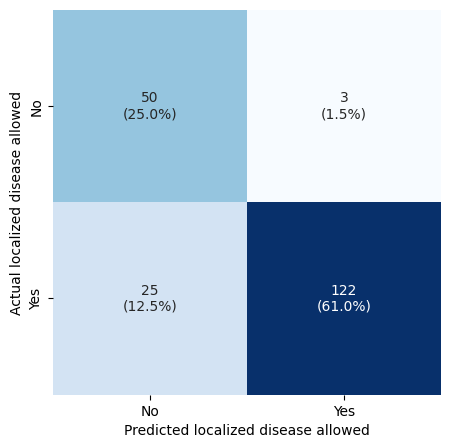

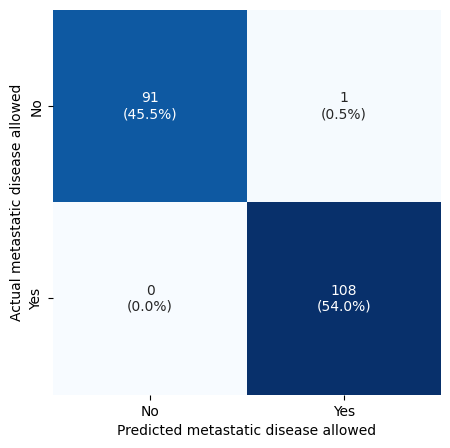

In [8]:
# Confusion matrices for abstract
small_confusion_matrix("LOCAL", "ABSTRACT")
small_confusion_matrix("METASTATIC", "ABSTRACT")

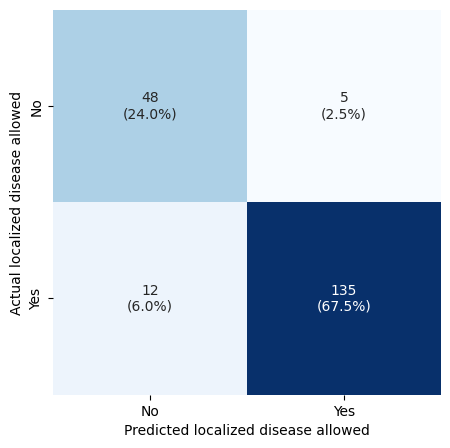

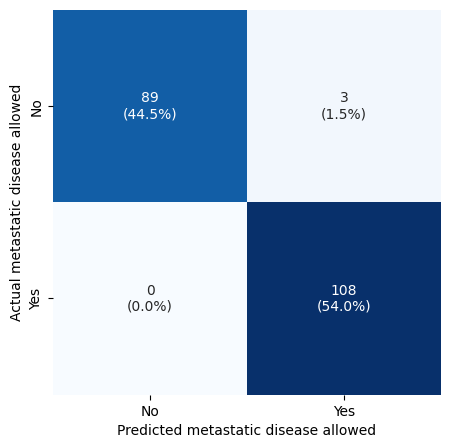

In [9]:
# Confusion matrices for full text
small_confusion_matrix("LOCAL", "FULL_TEXT")
small_confusion_matrix("METASTATIC", "FULL_TEXT")

In [10]:
# Statistical evaluation: accuracy, precision, recall, F1 score
def statistics(Label, Text): # labels must be strings in uppercase
    # Calculate the accuracy
    accuracy = (
        np.sum(table[Label] == table[f"{Text}_{Label}"])
        / table.shape[0]
    )
    # Estimate the 95 % confidence interval for the accuracy (Wilson)
    accuracy_CI_lower, accuracy_CI_upper = proportion_confint(
       count = np.sum(table[Label] == table[f"{Text}_{Label}"]),
       nobs = table.shape[0], 
       alpha = 0.05, 
       method = 'wilson'
   )
    print(
        f"Accuracy of {Text} prediction for {Label}: {accuracy:.2f} (95% CI: {accuracy_CI_lower:.2f} - {accuracy_CI_upper:.2f})"
    )    
    
    # Calculate the precision 
    precision = (
        np.sum(
            (table[Label] == 1) & (table[f"{Text}_{Label}"] == 1)
        )
        / np.sum(table[f"{Text}_{Label}"] == 1)
    )
    # Estimate the 95 % confidence interval for the precision (Wilson)
    precision_CI_lower, precision_CI_upper = proportion_confint(
       count = np.sum((table[Label] == 1) & (table[f"{Text}_{Label}"] == 1)),
       nobs = np.sum(table[f"{Text}_{Label}"] == 1), 
       alpha = 0.05, 
       method = 'wilson'
   )
    print(f"Precision of {Text} prediction for {Label}: {precision:.2f} (95% CI: {precision_CI_lower:.2f} - {precision_CI_upper:.2f})")
    
    # Calculate the recall
    recall = (
        np.sum(
            (table[Label] == 1) & (table[f"{Text}_{Label}"] == 1)
        )
        / np.sum(table[Label] == 1)
    )
    # Estimate the 95 % confidence interval for the recall (Wilson)
    recall_CI_lower, recall_CI_upper = proportion_confint(
       count = np.sum((table[Label] == 1) & (table[f"{Text}_{Label}"] == 1)),
       nobs = np.sum(table[Label] == 1), 
       alpha = 0.05, 
       method = 'wilson'
   )
    print(
        f"Recall of {Text} prediction for {Label}: {recall:.2f} (95% CI: {recall_CI_lower:.2f} - {recall_CI_upper:.2f})"
    )
    
    # Calculate the F1 score 
    f1 = 2 * precision * recall / (precision + recall)
    # Estimate the 95 % confidence interval for the F1 score via Bootstrap
    boot_f1_values = []
    for i in range(10000):
        boot_table = table.sample(
            n=len(table),
            replace=True,
        )
        
        true_positives = np.sum((boot_table[Label] == 1) & (boot_table[f"{Text}_{Label}"] == 1)) # TP
        predicted_positives = np.sum(boot_table[f"{Text}_{Label}"] == 1) # TP + FP
        annotated_positives = np.sum(boot_table[Label] == 1) # TP + FN
        
        if true_positives == 0 or predicted_positives == 0 or annotated_positives == 0:
            continue #jumps to next iteration
        
        boot_precision = true_positives / predicted_positives
        boot_recall = true_positives / annotated_positives

        boot_f1 = 2 * boot_precision * boot_recall / (boot_precision + boot_recall)
        
        boot_f1_values.append(boot_f1)
        
    f1_CI_lower = np.percentile(boot_f1_values, 2.5)
    f1_CI_upper = np.percentile(boot_f1_values, 97.5)

    print(f"F1 score of {Text} prediction for {Label}: {f1:.2f} (95% CI: {f1_CI_lower:.2f} - {f1_CI_upper:.2f})")


In [11]:
statistics("LOCAL","ABSTRACT")

Accuracy of ABSTRACT prediction for LOCAL: 0.86 (95% CI: 0.81 - 0.90)
Precision of ABSTRACT prediction for LOCAL: 0.98 (95% CI: 0.93 - 0.99)
Recall of ABSTRACT prediction for LOCAL: 0.83 (95% CI: 0.76 - 0.88)
F1 score of ABSTRACT prediction for LOCAL: 0.90 (95% CI: 0.86 - 0.93)


In [12]:
statistics("LOCAL","FULL_TEXT")

Accuracy of FULL_TEXT prediction for LOCAL: 0.92 (95% CI: 0.87 - 0.95)
Precision of FULL_TEXT prediction for LOCAL: 0.96 (95% CI: 0.92 - 0.98)
Recall of FULL_TEXT prediction for LOCAL: 0.92 (95% CI: 0.86 - 0.95)
F1 score of FULL_TEXT prediction for LOCAL: 0.94 (95% CI: 0.91 - 0.97)


In [13]:
statistics("METASTATIC","ABSTRACT")

Accuracy of ABSTRACT prediction for METASTATIC: 0.99 (95% CI: 0.97 - 1.00)
Precision of ABSTRACT prediction for METASTATIC: 0.99 (95% CI: 0.95 - 1.00)
Recall of ABSTRACT prediction for METASTATIC: 1.00 (95% CI: 0.97 - 1.00)
F1 score of ABSTRACT prediction for METASTATIC: 1.00 (95% CI: 0.99 - 1.00)


In [14]:
statistics("METASTATIC","FULL_TEXT")

Accuracy of FULL_TEXT prediction for METASTATIC: 0.98 (95% CI: 0.96 - 0.99)
Precision of FULL_TEXT prediction for METASTATIC: 0.97 (95% CI: 0.92 - 0.99)
Recall of FULL_TEXT prediction for METASTATIC: 1.00 (95% CI: 0.97 - 1.00)
F1 score of FULL_TEXT prediction for METASTATIC: 0.99 (95% CI: 0.97 - 1.00)


In [15]:
def McNemar_accuracy(Label): # Label = "LOCAL", "METASTATIC" or "ALL_LABELS"
    print ("P-value calculation using McNemar test for accuracy of", Label)
    a = np.sum(
        (table[Label] == table[f"ABSTRACT_{Label}"]) &
        (table[Label] == table[f"FULL_TEXT_{Label}"])
    ) # Abstract and full text correct
    print("a =", a)

    b = np.sum(
        (table[Label] == table[f"ABSTRACT_{Label}"]) &
        (table[Label] != table[f"FULL_TEXT_{Label}"])
    ) # Abstract correct, full text incorrect
    print("b =", b)

    c = np.sum(
        (table[Label] != table[f"ABSTRACT_{Label}"]) &
        (table[Label] == table[f"FULL_TEXT_{Label}"])
    ) # Abstract incorrect, full text correct
    print("c =", c)

    d = np.sum(
        (table[Label] != table[f"ABSTRACT_{Label}"]) &
        (table[Label] != table[f"FULL_TEXT_{Label}"])
    ) # Abstract and full text incorrect
    print("d =", d)

    # Run McNemar test
    contingency_table = [[a, b],
                     [c, d]]

    P_accuracy_Label = mcnemar(contingency_table, exact=True)
    print("Chi-Quadrat=", P_accuracy_Label.statistic, ", P-Wert = ", P_accuracy_Label.pvalue)
    

In [16]:
McNemar_accuracy("LOCAL")

P-value calculation using McNemar test for accuracy of LOCAL
a = 167
b = 5
c = 16
d = 12
Chi-Quadrat= 5.0 , P-Wert =  0.02660369873046875


In [17]:
McNemar_accuracy("METASTATIC")

P-value calculation using McNemar test for accuracy of METASTATIC
a = 197
b = 2
c = 0
d = 1
Chi-Quadrat= 0.0 , P-Wert =  0.5


In [18]:
McNemar_accuracy("ALL_LABELS")

P-value calculation using McNemar test for accuracy of ALL_LABELS
a = 167
b = 5
c = 16
d = 12
Chi-Quadrat= 5.0 , P-Wert =  0.02660369873046875


ABSTRACT_ALL_LABELS  Both  Local_only  Metastatic_only  Neither
ALL_LABELS                                                     
Both                   50           0               25        0
Local_only              0          72                0        0
Metastatic_only         0           0               33        0
Neither                 1           2                0       17


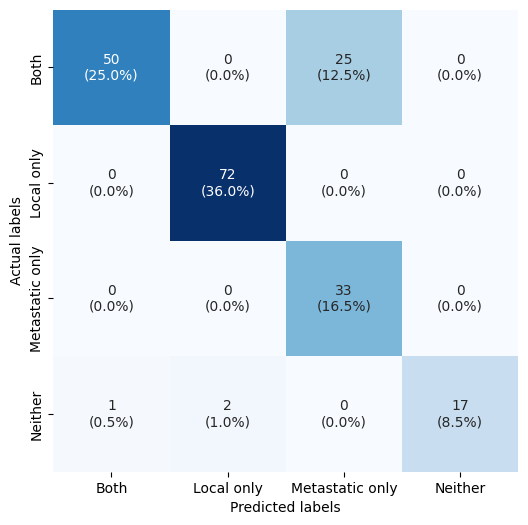

In [19]:
# Create the confusion matrix of predicted and actual values for combined labels
confusion_matrix = pd.crosstab(
    table["ALL_LABELS"], table["ABSTRACT_ALL_LABELS"]
)
print (confusion_matrix)

# Add a column called "Neither" and fill it with zeros if it does not exist
if "Neither" not in confusion_matrix.columns:
    confusion_matrix["Neither"] = 0

# Add percentage to the absolute number
labels = np.array([
f"{count}\n({count/2:.1f}%)" # Total number is always 200 so divide by 2 to get percentage
for count in confusion_matrix.values.flatten()
]).reshape(confusion_matrix.shape)

# Plot the confusion matrix
fig = plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix, annot=labels, cmap="Blues", fmt="")


plt.xlabel("Predicted labels")
plt.ylabel("Actual labels")
plt.xticks([0.5, 1.5, 2.5, 3.5], ["Both", "Local only", "Metastatic only", "Neither"])
plt.yticks([0.5, 1.5, 2.5, 3.5], ["Both", "Local only", "Metastatic only", "Neither"])
# Remove the colorbar but keep the width of the heatmap
plt.gca().collections[0].colorbar.remove()
plt.show()

fig.savefig("confusion_matrix_all_labels_ABSTRACT_percentage.png", dpi=300, bbox_inches="tight")

FULL_TEXT_ALL_LABELS  Both  Local_only  Metastatic_only  Neither
ALL_LABELS                                                      
Both                    63           0               12        0
Local_only               0          72                0        0
Metastatic_only          1           0               32        0
Neither                  3           1                0       16


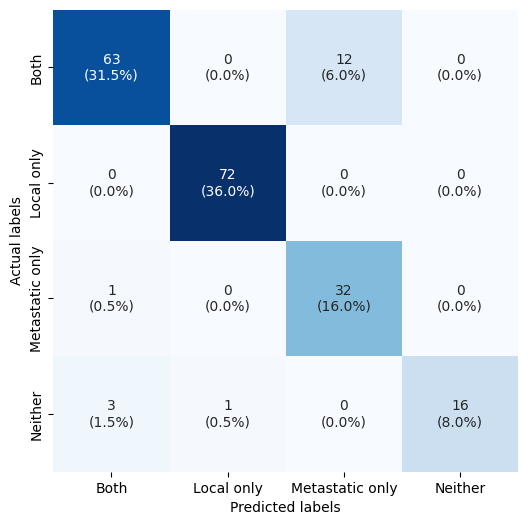

In [20]:
# Create the confusion matrix of predicted and actual values for combined labels
confusion_matrix = pd.crosstab(
    table["ALL_LABELS"], table["FULL_TEXT_ALL_LABELS"]
)
print (confusion_matrix)

# Add a column called "Neither" and fill it with zeros if it does not exist
if "Neither" not in confusion_matrix.columns:
    confusion_matrix["Neither"] = 0
    
# Add percentage to the absolute number
labels = np.array([
f"{count}\n({count/2:.1f}%)" # Total number is always 200 so divide by 2 to get percentage
for count in confusion_matrix.values.flatten()
]).reshape(confusion_matrix.shape)

# Plot the confusion matrix
fig = plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix, annot=labels, cmap="Blues", fmt="")


plt.xlabel("Predicted labels")
plt.ylabel("Actual labels")
plt.xticks([0.5, 1.5, 2.5, 3.5], ["Both", "Local only", "Metastatic only", "Neither"])
plt.yticks([0.5, 1.5, 2.5, 3.5], ["Both", "Local only", "Metastatic only", "Neither"])
# Remove the colorbar but keep the width of the heatmap
plt.gca().collections[0].colorbar.remove()
plt.show()

fig.savefig("confusion_matrix_all_labels_FULL_TEXT_percentage.png", dpi=300, bbox_inches="tight")

In [21]:
#Statistics für all Labels

# Calculate the accuracy for all labels ABSTRACT
accuracy_combined_abstract = (
    np.sum(table["ALL_LABELS"] == table["ABSTRACT_ALL_LABELS"])
    / table.shape[0]
)
# Estimate the 95 % confidence interval for the accuracy of all labels ABSTRACT (Wilson)
accuracy_comb_abstr_CI_lower, accuracy_comb_abstr_CI_upper = proportion_confint(
    count = np.sum(table["ALL_LABELS"] == table["ABSTRACT_ALL_LABELS"]),
    nobs = table.shape[0], 
    alpha = 0.05, 
    method = 'wilson'
)

print(
    f"Accuracy of all labels with ABSTRACT: {accuracy_combined_abstract:.2f} (95% CI: {accuracy_comb_abstr_CI_lower:.2f} - {accuracy_comb_abstr_CI_upper:.2f})"
)
print("##############################################")

# Calculate the accuracy for all labels FULL_TEXT
accuracy_combined_fulltext = (
    np.sum(table["ALL_LABELS"] == table["FULL_TEXT_ALL_LABELS"])
    / table.shape[0]
)
# Estimate the 95 % confidence interval for the accuracy of all labels FULL TEXT (Wilson)
accuracy_comb_ft_CI_lower, accuracy_comb_ft_CI_upper = proportion_confint(
    count = np.sum(table["ALL_LABELS"] == table["FULL_TEXT_ALL_LABELS"]),
    nobs = table.shape[0], 
    alpha = 0.05, 
    method = 'wilson'
)


print(
    f"Accuracy of all labels with FULL_TEXT: {accuracy_combined_fulltext:.2f} (95% CI: {accuracy_comb_ft_CI_lower:.2f} - {accuracy_comb_ft_CI_upper:.2f})"
)


    

Accuracy of all labels with ABSTRACT: 0.86 (95% CI: 0.81 - 0.90)
##############################################
Accuracy of all labels with FULL_TEXT: 0.92 (95% CI: 0.87 - 0.95)


In [22]:
def Precision_Recall_F1_ALL_LABELS(TEXT, AL):    
    # Calculate the precision
    precision = (
        np.sum(
            (table["ALL_LABELS"] == AL) & (table[f"{TEXT}_ALL_LABELS"] == AL)
        )
        / np.sum(table[f"{TEXT}_ALL_LABELS"] == AL)
    )

    # Estimate the 95 % confidence interval for the precision (Wilson)
    precision_CI_lower, precision_CI_upper = proportion_confint(
        count = np.sum((table["ALL_LABELS"] == AL) & (table[f"{TEXT}_ALL_LABELS"] == AL)),
        nobs = np.sum(table[f"{TEXT}_ALL_LABELS"] == AL), 
        alpha = 0.05, 
        method = 'wilson'
    )

    print(f"Precision for {AL} - {TEXT}: {precision:.2f} (95% CI: {precision_CI_lower:.2f} - {precision_CI_upper:.2f})")
    
    # Calculate the recall
    recall = (
        np.sum(
            (table["ALL_LABELS"] == AL) & (table[f"{TEXT}_ALL_LABELS"] == AL)
        )
        / np.sum(table["ALL_LABELS"] == AL)
    )

    # Estimate the 95 % confidence interval for the recall (Wilson
    recall_CI_lower, recall_CI_upper = proportion_confint(
        count = np.sum((table["ALL_LABELS"] == AL) & (table[f"{TEXT}_ALL_LABELS"] == AL)),
        nobs = np.sum(table["ALL_LABELS"] == AL), 
        alpha = 0.05, 
        method = 'wilson'
    )
    print(
        f"Recall for {AL} - {TEXT}: {recall:.2f} (95% CI: {recall_CI_lower:.2f} - {recall_CI_upper:.2f})"
    )

    # Calculate the F1 score of the ML model for Both
    f1 = 2 * precision * recall / (precision + recall)

    # Estimate the 95 % confidence interval for the F1 score via Bootstrap
    boot_f1_values = []
    for i in range(10000):
        boot_table = table.sample(
            n=len(table),
            replace=True,
        )
        
        true_positives = np.sum((boot_table["ALL_LABELS"] == AL) & (boot_table[f"{TEXT}_ALL_LABELS"] == AL))# TP
        predicted_positives = np.sum(boot_table[f"{TEXT}_ALL_LABELS"] == AL) # TP + FP
        annotated_positives = np.sum(boot_table["ALL_LABELS"] == AL) # TP + FN
        
        if true_positives == 0 or predicted_positives == 0 or annotated_positives == 0:
            continue #jumps to next iteration
        
        boot_precision = true_positives / predicted_positives
        boot_recall = true_positives / annotated_positives

        boot_f1 = 2 * boot_precision * boot_recall / (boot_precision + boot_recall)
        
        boot_f1_values.append(boot_f1)
        
    f1_CI_lower = np.percentile(boot_f1_values, 2.5)
    f1_CI_upper = np.percentile(boot_f1_values, 97.5)
    
    print(f"F1 score for {AL} - {TEXT}: {f1:.2f} (95% CI: {f1_CI_lower:.2f} - {f1_CI_upper:.2f})")
    print("##############################################")


In [23]:
Precision_Recall_F1_ALL_LABELS("ABSTRACT", "Both")
Precision_Recall_F1_ALL_LABELS("ABSTRACT", "Local_only")
Precision_Recall_F1_ALL_LABELS("ABSTRACT", "Metastatic_only")
Precision_Recall_F1_ALL_LABELS("ABSTRACT", "Neither")

Precision for Both - ABSTRACT: 0.98 (95% CI: 0.90 - 1.00)
Recall for Both - ABSTRACT: 0.67 (95% CI: 0.55 - 0.76)
F1 score for Both - ABSTRACT: 0.79 (95% CI: 0.71 - 0.87)
##############################################
Precision for Local_only - ABSTRACT: 0.97 (95% CI: 0.91 - 0.99)
Recall for Local_only - ABSTRACT: 1.00 (95% CI: 0.95 - 1.00)
F1 score for Local_only - ABSTRACT: 0.99 (95% CI: 0.96 - 1.00)
##############################################
Precision for Metastatic_only - ABSTRACT: 0.57 (95% CI: 0.44 - 0.69)
Recall for Metastatic_only - ABSTRACT: 1.00 (95% CI: 0.90 - 1.00)
F1 score for Metastatic_only - ABSTRACT: 0.73 (95% CI: 0.61 - 0.82)
##############################################
Precision for Neither - ABSTRACT: 1.00 (95% CI: 0.82 - 1.00)
Recall for Neither - ABSTRACT: 0.85 (95% CI: 0.64 - 0.95)
F1 score for Neither - ABSTRACT: 0.92 (95% CI: 0.80 - 1.00)
##############################################


In [24]:
Precision_Recall_F1_ALL_LABELS("FULL_TEXT", "Both")
Precision_Recall_F1_ALL_LABELS("FULL_TEXT", "Local_only")
Precision_Recall_F1_ALL_LABELS("FULL_TEXT", "Metastatic_only")
Precision_Recall_F1_ALL_LABELS("FULL_TEXT", "Neither")

Precision for Both - FULL_TEXT: 0.94 (95% CI: 0.86 - 0.98)
Recall for Both - FULL_TEXT: 0.84 (95% CI: 0.74 - 0.91)
F1 score for Both - FULL_TEXT: 0.89 (95% CI: 0.83 - 0.94)
##############################################
Precision for Local_only - FULL_TEXT: 0.99 (95% CI: 0.93 - 1.00)
Recall for Local_only - FULL_TEXT: 1.00 (95% CI: 0.95 - 1.00)
F1 score for Local_only - FULL_TEXT: 0.99 (95% CI: 0.98 - 1.00)
##############################################
Precision for Metastatic_only - FULL_TEXT: 0.73 (95% CI: 0.58 - 0.84)
Recall for Metastatic_only - FULL_TEXT: 0.97 (95% CI: 0.85 - 0.99)
F1 score for Metastatic_only - FULL_TEXT: 0.83 (95% CI: 0.72 - 0.91)
##############################################
Precision for Neither - FULL_TEXT: 1.00 (95% CI: 0.81 - 1.00)
Recall for Neither - FULL_TEXT: 0.80 (95% CI: 0.58 - 0.92)
F1 score for Neither - FULL_TEXT: 0.89 (95% CI: 0.76 - 0.98)
##############################################
